In [1]:
!pip install transformers datasets torch nltk -q

In [2]:
import torch
import nltk
from datasets import load_dataset
from transformers import AutoTokenizer

nltk.download('punkt')

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


PyTorch version: 2.11.0+cu128
GPU available: True


In [4]:
dataset = load_dataset("code-search-net/code_search_net", "python")
print(dataset)

README.md:   0%|          | 0.00/14.1k [00:00<?, ?B/s]

python/train-00000-of-00001.parquet:   0%|          | 0.00/522M [00:00<?, ?B/s]

python/test-00000-of-00001.parquet:   0%|          | 0.00/28.7M [00:00<?, ?B/s]

python/validation-00000-of-00001.parquet:   0%|          | 0.00/30.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/412178 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/22176 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/23107 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 412178
    })
    test: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 22176
    })
    validation: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_code_tokens', 'func_documentation_string', 'func_documentation_tokens', 'split_name', 'func_code_url'],
        num_rows: 23107
    })
})


In [5]:
# Sirf 50k training samples lo
train_data = dataset["train"].select(range(50000))
test_data = dataset["test"].select(range(2000))
val_data = dataset["validation"].select(range(2000))

# Sirf code aur comment columns chahiye, baaki sab hata do
def clean(sample):
    return {
        "code": sample["func_code_string"],
        "comment": sample["func_documentation_string"]
    }

train_data = train_data.map(clean, remove_columns=train_data.column_names)
test_data = test_data.map(clean, remove_columns=test_data.column_names)
val_data = val_data.map(clean, remove_columns=val_data.column_names)

# Empty strings filter karo
train_data = train_data.filter(lambda x: len(x["code"]) > 10 and len(x["comment"]) > 10)
test_data = test_data.filter(lambda x: len(x["code"]) > 10 and len(x["comment"]) > 10)
val_data = val_data.filter(lambda x: len(x["code"]) > 10 and len(x["comment"]) > 10)

print("Train size:", len(train_data))
print("Test size:", len(test_data))
print("Val size:", len(val_data))

# Ek sample dekho
print("\nSample Code:\n", train_data[0]["code"][:300])
print("\nSample Comment:\n", train_data[0]["comment"])

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/50000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train size: 49626
Test size: 1995
Val size: 1999

Sample Code:
 def __msgc_step3_discontinuity_localization(self):
        """
        Estimate discontinuity in basis of low resolution image segmentation.
        :return: discontinuity in low resolution
        """
        import scipy

        start = self._start_time
        seg = 1 - self.segmentation.astype(

Sample Comment:
 Estimate discontinuity in basis of low resolution image segmentation.
        :return: discontinuity in low resolution


In [8]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

MODEL_NAME = "t5-small"
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)

def tokenize(sample):
    input_enc = tokenizer(
        "summarize: " + sample["code"],
        max_length=256,
        truncation=True,
        padding="max_length"
    )
    target_enc = tokenizer(
        sample["comment"],
        max_length=64,
        truncation=True,
        padding="max_length"
    )
    input_enc["labels"] = target_enc["input_ids"]
    return input_enc

train_tokenized = train_data.map(tokenize, remove_columns=["code", "comment"])
test_tokenized = test_data.map(tokenize, remove_columns=["code", "comment"])
val_tokenized = val_data.map(tokenize, remove_columns=["code", "comment"])

print("Tokenization done.")

Map:   0%|          | 0/1995 [00:00<?, ? examples/s]

Tokenization done.


In [9]:
import torchvision
torchvision.disable_beta_transforms_warning()

train_tokenized.reset_format()
test_tokenized.reset_format()
val_tokenized.reset_format()

# Manually torch tensors banayenge training loop mein
# Abhi sirf verify karo keys
print("Train keys:", train_tokenized.column_names)
print("Sample input_ids length:", len(train_tokenized[0]["input_ids"]))
print("Sample labels length:", len(train_tokenized[0]["labels"]))
print("All good!")

Train keys: ['input_ids', 'attention_mask', 'labels']
Sample input_ids length: 256
Sample labels length: 64
All good!


In [10]:
import torch
from transformers import T5ForConditionalGeneration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = T5ForConditionalGeneration.from_pretrained("t5-small")
model = model.to(device)

print("Model loaded successfully!")
print("Total parameters:", sum(p.numel() for p in model.parameters()))

Using device: cuda


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded successfully!
Total parameters: 60506624


In [12]:
from torch.utils.data import DataLoader
from torch.optim import AdamW
import torch

def collate_fn(batch):
    input_ids = torch.tensor([item["input_ids"] for item in batch])
    attention_mask = torch.tensor([item["attention_mask"] for item in batch])
    labels = torch.tensor([item["labels"] for item in batch])
    labels[labels == tokenizer.pad_token_id] = -100
    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }

train_loader = DataLoader(train_tokenized, batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_tokenized, batch_size=16, shuffle=False, collate_fn=collate_fn)

optimizer = AdamW(model.parameters(), lr=5e-4)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Setup complete!")

Train batches: 3102
Val batches: 125
Setup complete!


In [13]:
from tqdm import tqdm

EPOCHS = 3

for epoch in range(EPOCHS):
    # Training
    model.train()
    total_train_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # Validation
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1} Validation"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_val_loss += outputs.loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    print(f"\nEpoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

print("\nTraining Complete!")

Epoch 1 Validation: 100%|██████████| 125/125 [00:14<00:00,  8.78it/s]



Epoch 1 | Train Loss: 0.0505 | Val Loss: 0.0305


Epoch 2 Validation: 100%|██████████| 125/125 [00:14<00:00,  8.79it/s]



Epoch 2 | Train Loss: 0.0198 | Val Loss: 0.0280


Epoch 3 Validation: 100%|██████████| 125/125 [00:14<00:00,  8.79it/s]


Epoch 3 | Train Loss: 0.0131 | Val Loss: 0.0184

Training Complete!


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import os

save_path = "/content/drive/MyDrive/CCP_Model"
os.makedirs(save_path, exist_ok=True)

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("Model saved at:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved at: /content/drive/MyDrive/CCP_Model


In [16]:
model.eval()

def generate_comment(code):
    input_text = "summarize: " + code
    input_ids = tokenizer(
        input_text,
        max_length=256,
        truncation=True,
        return_tensors="pt"
    ).input_ids.to(device)

    outputs = model.generate(
        input_ids,
        max_length=64,
        num_beams=4,
        early_stopping=True
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# 5 samples test karo
for i in range(5):
    sample = test_data[i]
    code = sample["code"]
    actual_comment = sample["comment"]
    generated_comment = generate_comment(code)

    print(f"--- Sample {i+1} ---")
    print(f"Actual:    {actual_comment[:100]}")
    print(f"Generated: {generated_comment}")
    print()

--- Sample 1 ---
Actual:    Extracts video ID from URL.
Generated: Extracts video ID from URL.

--- Sample 2 ---
Actual:    str->list
    Convert XML to URL List.
    From Biligrab.
Generated: str->list Convert XML to URL List. From Biligrab.

--- Sample 3 ---
Actual:    From http://cdn37.atwikiimg.com/sitescript/pub/dksitescript/FC2.site.js
    Also com.hps.util.fc2.FC
Generated: From http://cdn37.atwikiimg.com/sitescript/pub/dksitescript/FC2.site.js Also com.hps.util.fc2.FC2EncrptUtil.makeMimiLocal L110

--- Sample 4 ---
Actual:    Downloads Dailymotion videos by URL.
Generated: Downloads Dailymotion videos by URL.

--- Sample 5 ---
Actual:    http://stackoverflow.com/a/30923963/2946714
Generated: https://stackoverflow.com/a/30923963/2946714



In [17]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import nltk
nltk.download('punkt_tab')

references = []
hypotheses = []

print("Generating predictions on test set (2000 samples)...")

for i in range(len(test_data)):
    sample = test_data[i]
    generated = generate_comment(sample["code"])
    actual = sample["comment"]

    references.append([actual.split()])
    hypotheses.append(generated.split())

smoothie = SmoothingFunction().method1

bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoothie)
bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)

print(f"BLEU-1 Score: {bleu1:.4f}")
print(f"BLEU-4 Score: {bleu4:.4f}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Generating predictions on test set (2000 samples)...
BLEU-1 Score: 0.1364
BLEU-4 Score: 0.1310


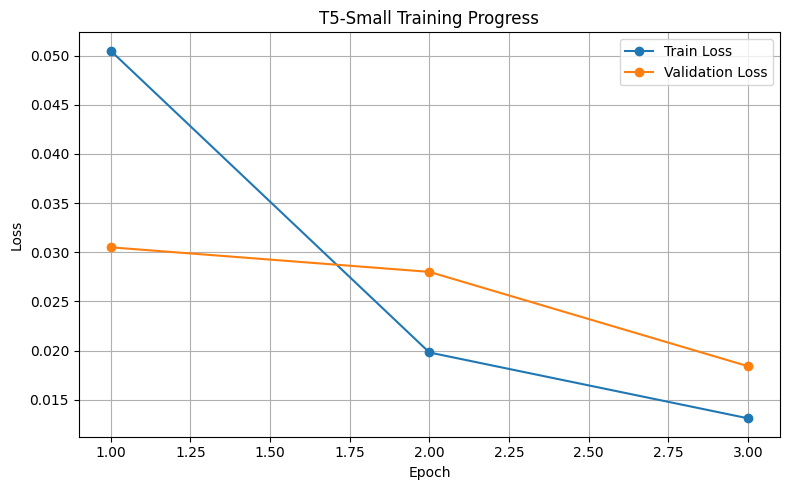

Plot saved!


In [18]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3]
train_losses = [0.0505, 0.0198, 0.0131]
val_losses = [0.0305, 0.0280, 0.0184]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='o', label='Validation Loss')
plt.title('T5-Small Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/CCP_Model/loss_curve.png")
plt.show()

print("Plot saved!")